In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

x = np.random.randn(100)

noise = np.random.randn(100)

TRUE_W = 2.0
TRUE_B = 1.0

y = TRUE_W * x + TRUE_B + noise


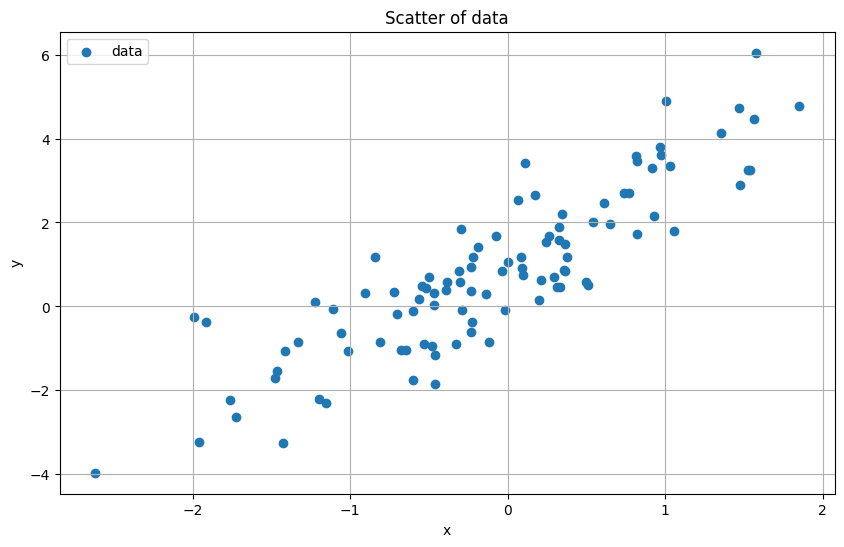

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(x=x, y=y, label='data')
plt.title('Scatter of data')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
#Mean Square Error - MSE
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

#Predict y
def predict(w, x, b):
    return w * x + b

1. In notebook 02 you eyeballed `w, b` and computed MSE. What's wrong with eyeballing as a strategy when you have 50 features instead of 1?
   - It becomes complex when you have more features in order to eyeball `w, b`.
   - It takes more time to compute `w, b`.
   - It is hectic to calculate.
   - More importantly, you cannot easily guess what will give low MSE.
2. The MSE surface is a **bowl** in `(w, b)` space. If a blindfolded person stood on the bowl and wanted to reach the bottom, what's the one piece of local info they'd need at every step?
   - The person might need the slope, how much slope it has, is it very steep down, its not that much steep or its managable steep.
3. Define **gradient** in one sentence — not the textbook def, *your* def.
   - Gardient can be anything pointing to upward direction, if w is positive and
     it can downward, if it is negative, if it is zero, then there is no slope.
     And gradient will define, what is the rate of change error(MSE) w.r.t change in w,
     what is the rate of change error(MSE) w.r.t change in b
4. Why "descent" and not "ascent"?
   - ascent means bigger loss, we do not want bigger loss, descent means less loss, inorder to have loss we should be moving towards descent.
5. What's the role of **learning rate** — 1 sentence.
   - learning rate will be how much unit you should move not very high, not very less,
     how much sufficient.

For linreg with ŷ = w·x + b and MSE = (1/n) Σ (y_i − ŷ_i)²

- the rate of change of MSE w.r.t w is : (-2/n) Σ x_i (y_i − ŷ_i)
- the rate of change of MSE w.r.t b is : (-2/n) Σ (y_i − ŷ_i)

Gradient is nothing but the rate of change of MSE w.r.t w, and rate of change of MSE w.r.t b


In [17]:
np.random.seed(42)
n = 100
x = np.random.uniform(0, 10, n)

y = 3 * x + 5 + np.random.normal(0, 2, n) #True_w = 3 and True_b = 5
print(mse(y, predict(w=3, x=x, b=5)))
print(x[:5])
print(y[:5])

3.3004271196317525
[3.74540119 9.50714306 7.31993942 5.98658484 1.5601864 ]
[16.4102977  32.92341449 27.14333981 18.9846167   9.24121544]


In [20]:
def gradients(x, y, w, b):
    y_cap = predict(w=w,x=x, b=b)
    error = y - y_cap
    dw = (-2/n) * np.sum(x * error)
    db = (-2/n) * np.sum(error)
    return dw, db

dw_true, db_true = gradients(x=x,y=y,w=3,b=5)
print(f'dw_true is :{dw_true:.4f}, db_true is : {db_true:.4f}')
# got dw_true is :-0.7413, db_true is : -0.2159, so increase dw_true and db__true

dw_fake, db_fake = gradients(x=x,y=y,w=0,b=0)
print(f'dw_fake is :{dw_fake:.4f}, db_fake is : {db_fake:.4f}')


dw_true is :1.6316, db_true is : 0.0043
dw_fake is :-230.5974, db_fake is : -38.2065


In [23]:
def gradiant_descent(x, y, lr=0.01, epochs=1000):
    w, b = 0, 0
    
    history = []

    for epoch in range(epochs):
        dw, db = gradients(x, y, w, b)
        w = w - lr * dw
        b = b - lr * db
        loss = mse(y_true=y, y_pred=predict(w,x=x,b=b))
        history.append(loss)
        if epoch % 100 == 0:
            print(f'epoch {epoch}, | w = {w:.3f}, b = {b:.3f} | loss = {loss:.3f}')
    return w, b, history
    
w_hat, b_hat, hist = gradiant_descent(x=x, y=y, lr=0.01, epochs=1000)
print(len(hist))
print(f"\nFinal: w={w_hat:.3f} (truth 3.0), b={b_hat:.3f} (truth 5.0)")



epoch 0, | w = 2.306, b = 0.382 | loss = 68.480
epoch 100, | w = 3.335, b = 2.654 | loss = 5.414
epoch 200, | w = 3.153, b = 3.839 | loss = 3.945
epoch 300, | w = 3.048, b = 4.518 | loss = 3.463
epoch 400, | w = 2.988, b = 4.907 | loss = 3.304
epoch 500, | w = 2.954, b = 5.130 | loss = 3.252
epoch 600, | w = 2.934, b = 5.258 | loss = 3.235
epoch 700, | w = 2.923, b = 5.332 | loss = 3.229
epoch 800, | w = 2.917, b = 5.374 | loss = 3.227
epoch 900, | w = 2.913, b = 5.398 | loss = 3.227
1000

Final: w=2.911 (truth 3.0), b=5.411 (truth 5.0)


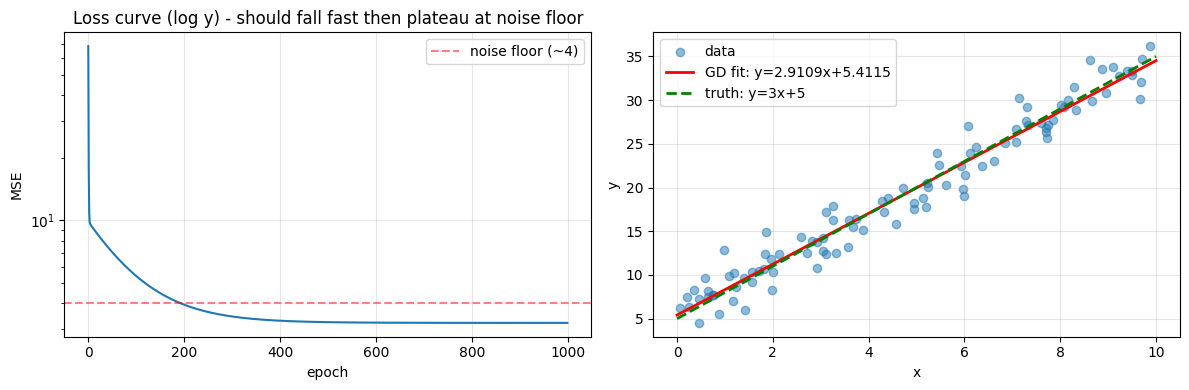

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist);
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].set_title("Loss curve (log y) - should fall fast then plateau at noise floor")
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=4.0, color='red', linestyle='--', alpha=0.5, label='noise floor (~4)')
axes[0].legend()

axes[1].scatter(x, y, alpha=0.5, label='data')
x_line = np.linspace(0, 10, 50)
axes[1].plot(x_line, predict(w_hat, x_line, b_hat), 'r-', linewidth=2, label=f'GD fit: y={w_hat:.4f}x+{b_hat:.4f}')
axes[1].plot(x_line, predict(3.0,x_line,5.0),'g--', linewidth=2, label='truth: y=3x+5')
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## L4 — Reflection: what does learning rate actually control?

### Experiment 1: lr = 0.1 (10× the working value)

**My prediction before running:** If i increase the learning rate, the curve which we have drawn above the flat line does comes faster which means you reach to the true w and true b a quicker than before

In [25]:
w_big, b_big, hist_big = gradiant_descent(x, y, lr=0.1, epochs=1000)

print(f'Final w={w_big}, b={b_big}')
print(f'Final MSE: {hist_big[-1]}')
print(f'First 10 MSE values : {hist_big[:10]}')


epoch 0, | w = 23.060, b = 3.821 | loss = 12236.216
epoch 100, | w = 73369440146678210450243330891000729775317486003042780321967763876044865536.000, b = 11276758212228217884213615867693852491413464887443570655882859602807619584.000 | loss = 174074807924497796599043484600690079110269899242931694738988202728597346622735421326891143631664538808640957528260928794070176352219436738306746875904.000
epoch 200, | w = 276836559969536541146927216809640784736750484974578330483637444690538855123028933415394797377354476444350743845309283832133761609979354448507437056.000, b = 42549308606422835234578737389786942370629194138765135233305088251084097823255741077086734474439942749946530065440528427637443526751758301614047232.000 | loss = 247829158509655888501476381316249017140848369421918181604276278397818838458609879636953735480257263425239754033647251599337276686203374788769229056432455240973950470246676248508895276116433856712810771472265763771702591512777084436645746468950154997678305941538690853053

d:\ai-engineering-journey\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Admin\AppData\Local\Temp\ipykernel_12676\2038210961.py:3: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred)**2)
d:\ai-engineering-journey\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Admin\AppData\Local\Temp\ipykernel_12676\3364659982.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * dw


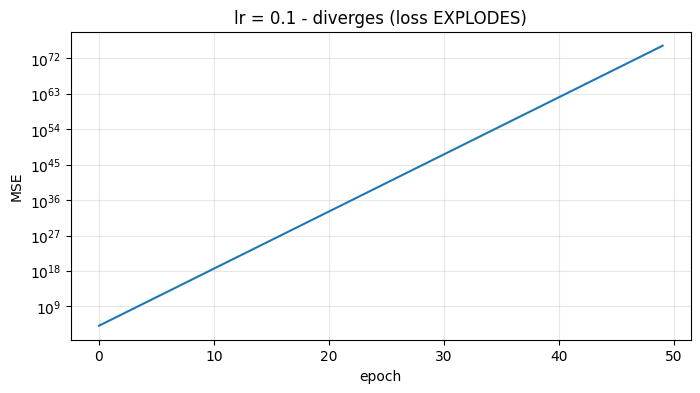

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(hist_big[:50])
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("lr = 0.1 - diverges (loss EXPLODES)")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()

**What I observed:** The MSE is increasing as epoch increases for first 50 epcohs

**Why it happened:** When lr is too big, each step **overshoots** the minimum. The
gradient says "go this way 6 units"; we leap 60 units, land HIGHER on the other side
of the bowl. Next step's gradient is even bigger, so we leap further again. Loss
explodes to infinity → numpy gives NaN.

### Experiment 2: lr = 0.0001 (100× smaller than working)

**My prediction:** true gradient might not be reached with in given epochs because the learning rate is too small.

In [27]:
w_tiny, b_tiny, hist_tiny = gradiant_descent(x,y, 0.0001,1000)

print(f'Final w_tiny={w_tiny:.4f} true_w = 5, b_tiny={b_tiny:.4f} true_b = 3')
print(f'Final MSE: {hist_tiny[-1]:.3f} (noise floor ~4)')

epoch 0, | w = 0.023, b = 0.004 | loss = 436.808
epoch 100, | w = 1.724, b = 0.293 | loss = 130.035
epoch 200, | w = 2.625, b = 0.459 | loss = 43.629
epoch 300, | w = 3.101, b = 0.559 | loss = 19.254
epoch 400, | w = 3.352, b = 0.625 | loss = 12.342
epoch 500, | w = 3.483, b = 0.672 | loss = 10.345
epoch 600, | w = 3.551, b = 0.709 | loss = 9.733
epoch 700, | w = 3.585, b = 0.741 | loss = 9.511
epoch 800, | w = 3.601, b = 0.770 | loss = 9.399
epoch 900, | w = 3.608, b = 0.797 | loss = 9.319
Final w_tiny=3.6094 true_w = 5, b_tiny=0.8237 true_b = 3
Final MSE: 9.249 (noise floor ~4)


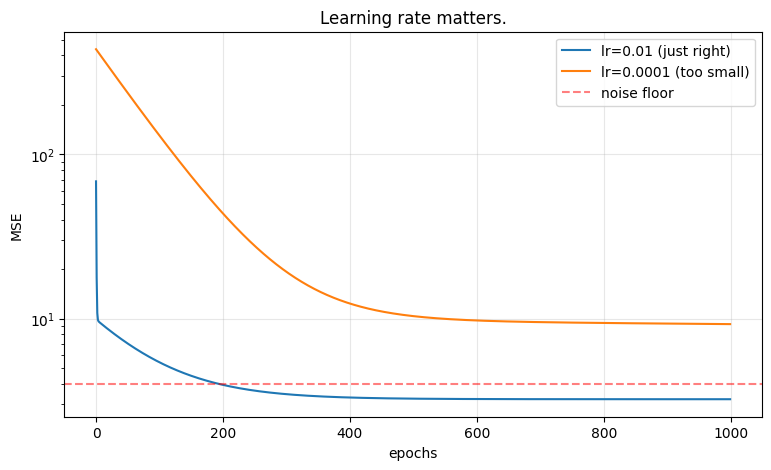

In [28]:
plt.figure(figsize=(9, 5))
plt.plot(hist, label='lr=0.01 (just right)')
plt.plot(hist_tiny, label='lr=0.0001 (too small)')
#plt.plot(hist_big, label='lr=0.1 (too big)') skipping this as it breaks the log plot
plt.xlabel('epochs')
plt.ylabel('MSE')
plt.yscale('log')
plt.axhline(y=4.0, color='red', linestyle='--', alpha=0.5, label='noise floor')
plt.title('Learning rate matters.')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**What I observed:** the too small lr did not reach the noise floor

**Why it happened:** Each step is so tiny that even after 1000 epochs we're still
far from the bottom of the bowl. Loss is still dropping but glacially.

### L4 Reflection — answers (in my own words)

**1. What is learning rate, in 1 sentence?**
learning rate will be, at what step rate we can reduce w(gradiant) and b values so that we can reach the true w, b values.

**2. Why is starting w=0, b=0 fine here but a terrible idea for neural nets?**
linear regression has only one convex, but not for the neural nets, neural net has so many local minima + saddle point, if we start w=0, b=0 every neural net will become identical, they stay identical forever.

**3. Bridge to Week 5:** "Gradient descent on MSE for linreg is convex → guaranteed
global minimum. For neural nets, the loss surface is ___."

**4. The single most important thing I learned today:**
The most satisfying part for me today is that, the example we have taken to plot the gradients we already what will be the true_w and true_b, and when we have derived gradients as we have know the answers it is very easy to what are we doing correctly or incorrectly. Along with this most satisfying part for me is deriving the gradient formulas, the rate of change of MSE w.r.t w and b.